# Rolling Elevation Mapping Demo
This notebook simulates a robot that scans a wavy ground-truth surface, estimates a rolling elevation map via a linear factor graph, and visualises both the grid snapshot and a robot-centric 3D view. The sections below document every component together with the equations they implement.


In [52]:
from SyntheticElevationDataLib import (
    TerrainConfig,
    TreePatch,
    evaluate_ground_truth,
    SensorConfig,
    simulate_lidar_measurements,
    generate_random_boxes,
)
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


## Ground-truth surface
The terrain is defined analytically by
\[
 h(x,y) = \sin	frac{x}{1.5} + 0.8\cos	frac{y}{1.2} + 0.4\sin	frac{x+y}{0.8} + 0.2\cos	frac{x-y}{0.5},
\]
which mixes multiple spatial frequencies so that the mapper has to resolve both long and short undulations.

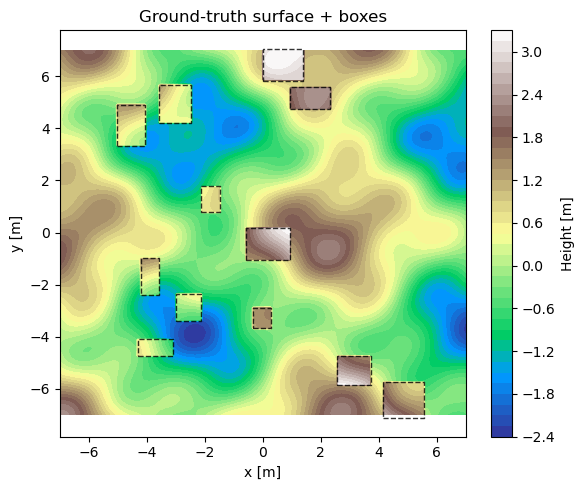

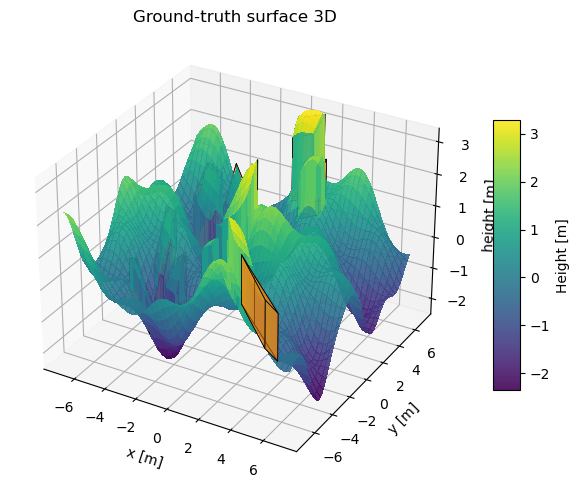

In [53]:
random_boxes = generate_random_boxes(
    num_boxes=12,
    x_range=(-6.5, 6.5),
    y_range=(-6.5, 6.5),
    size_range=(0.6, 1.6),
    height_range=(1.0, 2.0),
    seed=7,
)

terrain_config = TerrainConfig(
    enable_trees=False,
    patches=[
        TreePatch(center=(-3.5, -1.0), sigma=0.4, height=1.6),
        TreePatch(center=(0.5, 1.5), sigma=0.45, height=2.0),
        TreePatch(center=(3.0, -2.5), sigma=0.5, height=1.9),
    ],
    boxes=random_boxes,
)

terrain_without_boxes = TerrainConfig(
    enable_trees=terrain_config.enable_trees,
    patches=terrain_config.patches,
    boxes=[],
)


def ground_truth_height(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    x_arr = np.asarray(x)
    y_arr = np.asarray(y)
    return evaluate_ground_truth(x_arr, y_arr, terrain_config)


# Visualisiere den Ground-Truth inkl. Bäume/Boxen (2D + 3D)
x_range = np.linspace(-7, 7, 240)
y_range = np.linspace(-7, 7, 240)
X, Y = np.meshgrid(x_range, y_range)
Z = ground_truth_height(X, Y)
plt.figure(figsize=(6, 5))
cs = plt.contourf(X, Y, Z, levels=40, cmap='terrain')
if terrain_config.boxes:
    for box in terrain_config.boxes:
        half_x = box.size[0] / 2.0
        half_y = box.size[1] / 2.0
        cx, cy = box.center
        rect_x = [cx - half_x, cx + half_x, cx + half_x, cx - half_x, cx - half_x]
        rect_y = [cy - half_y, cy - half_y, cy + half_y, cy + half_y, cy - half_y]
        plt.plot(rect_x, rect_y, color='k', linewidth=1.0, linestyle='--', alpha=0.8)
plt.colorbar(cs, label='Height [m]')
title = 'Ground-truth surface'
if terrain_config.enable_trees:
    title += ' (with trees)'
if terrain_config.boxes:
    title += ' + boxes'
plt.title(title)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.tight_layout()
plt.show()

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=False, alpha=0.9)
if terrain_config.boxes:
    for box in terrain_config.boxes:
        half_x = box.size[0] / 2.0
        half_y = box.size[1] / 2.0
        cx, cy = box.center
        corners = [
            (cx - half_x, cy - half_y),
            (cx + half_x, cy - half_y),
            (cx + half_x, cy + half_y),
            (cx - half_x, cy + half_y),
        ]
        base_z = [
            evaluate_ground_truth(
                np.array([px]),
                np.array([py]),
                terrain_without_boxes,
            )[0]
            for px, py in corners
        ]
        top_z = [bz + box.height for bz in base_z]
        top = [(px, py, tz) for (px, py), tz in zip(corners, top_z)]
        bottom = [(px, py, bz) for (px, py), bz in zip(corners, base_z)]
        faces = [
            top,
            bottom,
        ]
        for idx in range(4):
            faces.append(
                [
                    top[idx],
                    top[(idx + 1) % 4],
                    bottom[(idx + 1) % 4],
                    bottom[idx],
                ]
            )
        poly = Poly3DCollection(
            faces,
            facecolor='tab:orange',
            edgecolor='k',
            linewidths=0.5,
            alpha=0.5,
        )
        ax.add_collection3d(poly)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('height [m]')
ax.set_title('Ground-truth surface 3D')
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10, label='Height [m]')
plt.tight_layout()
plt.show()


## Rolling elevation grid
The rolling buffer stores heights on a rectangular grid with resolution $\Delta$. World coordinates $(x,y)$ are converted to grid indices
\[
 g_x = \left\lfloor \rac{x - o_x}{\Delta} 
ight
floor, \qquad
 g_y = \left\lfloor \rac{y - o_y}{\Delta} 
ight
floor,
\]
and whenever the robot moves by $(d_x,d_y)$ the grid rolls by rounded index shifts so the robot remains near the centre. Newly uncovered cells are set to an unknown value.

## Linear factor graph formulation
Each grid cell $h_i$ becomes a node in a quadratic factor graph. Optimisation solves
\[
\min_{h} \sum_{(i,z)\in\mathcal{M}} rac{(h_i - z)^2}{\sigma^2}
        + \sum_{(i,j)\in\mathcal{S}} \lambda (h_i - h_j)^2
        + \sum_{(i,\mu,w)\in\mathcal{P}} w (h_i - \mu)^2,
\]
where $\mathcal{M}$ are measurement factors, $\mathcal{S}$ enforce first-order smoothness, and $\mathcal{P}$ inject the shifted previous estimate as a soft prior.

## Trajectory and sensor models
The robot can either follow a straight-line trajectory in the odom frame or remain static to accumulate random scans. For each pose $(x_r,y_r)$ we draw ray angles $	heta_k$ and ranges $r_k$, and compute endpoints via
\[
 p_k = (x_r + r_k\cos	heta_k,\; y_r + r_k\sin	heta_k,\; h(x_r + r_k\cos	heta_k, y_r + r_k\sin	heta_k)).
\]
The configurable sensor provides a forward-looking 120° fan or a randomised 360° pattern; the static experiment uses the latter to let new beams gradually densify the estimate.

In [54]:

# Trajektorie und Sensormodelle
NUM_STEPS = 40


def _make_line_poses():
    xs = np.linspace(-5.0, 5.0, NUM_STEPS)
    ys = np.zeros(NUM_STEPS)
    return np.vstack([xs, ys]).T


def _make_s_curve_poses():
    xs = np.linspace(-5.0, 5.0, NUM_STEPS)
    ys = 2.0 * np.sin(xs / 1.5)
    return np.vstack([xs, ys]).T


def _make_static_poses():
    return np.repeat(np.array([[0.0, 0.0]]), NUM_STEPS, axis=0)


EXPERIMENT_MODE = 'moving_line'
poses_odom = _make_line_poses()

sensor_config = SensorConfig(
    mode='forward_fan',
    sensor_height=1.0,
    ray_march_step=0.05,
    occlusion_eps=1e-3
)
SMOOTH_NEIGHBORHOOD = '4-connect'


def set_experiment_mode(new_mode: str):
    global EXPERIMENT_MODE, poses_odom
    EXPERIMENT_MODE = new_mode
    if new_mode == 'static_random':
        poses_odom = _make_static_poses()
    elif new_mode == 's_curve':
        poses_odom = _make_s_curve_poses()
    else:
        poses_odom = _make_line_poses()


def simulate_measurements_at_pose(
    x_odom: float,
    y_odom: float,
    num_rays: int = 5000,
    max_range: float = 5.0,
    mode: str = None,
):
    """
    LiDAR-Simulation über dem Gelände mit optionalen Ray-Marching-Okklusionen.
    """
    return simulate_lidar_measurements(
        x_odom,
        y_odom,
        ground_fn=ground_truth_height,
        sensor_cfg=sensor_config,
        num_rays=num_rays,
        max_range=max_range,
        mode=mode,
    )


### Sensor and experiment selectors
Use the dropdowns to choose the LiDAR pattern and the experiment type (moving line vs. static random accumulation) before running the reconstruction cell. Selecting the static experiment automatically switches to the 360° sensor so each time step contributes a fresh random scan while the robot remains at the origin.

In [67]:

import ipywidgets as widgets
from IPython.display import display

sensor_dropdown = widgets.Dropdown(
    options=[('Forward 120°', 'forward_fan'), ('Random 360°', 'random_360')],
    value=sensor_config.mode,
    description='Sensor:'
)

experiment_dropdown = widgets.Dropdown(
    options=[('Moving line', 'moving_line'), ('Static random', 'static_random'), ('S-curve', 's_curve')],
    value=EXPERIMENT_MODE,
    description='Experiment:'
)

smooth_dropdown = widgets.Dropdown(
    options=[('4-connect', '4-connect'), ('8-connect', '8-connect'), ('Diag only', 'diag-only')],
    value=SMOOTH_NEIGHBORHOOD,
    description='Smoothness:'
)

def _on_sensor_change(change):
    sensor_config.mode = change['new']


def _on_experiment_change(change):
    new_mode = change['new']
    if new_mode == 'static_random' and sensor_dropdown.value != 'random_360':
        sensor_dropdown.value = 'random_360'
    set_experiment_mode(new_mode)


def _on_smooth_change(change):
    global SMOOTH_NEIGHBORHOOD
    SMOOTH_NEIGHBORHOOD = change['new']
    if 'fg' in globals():
        fg.add_smoothness_factors_grid(SMOOTH_NEIGHBORHOOD)

sensor_dropdown.observe(_on_sensor_change, names='value')
experiment_dropdown.observe(_on_experiment_change, names='value')
smooth_dropdown.observe(_on_smooth_change, names='value')

display(widgets.VBox([sensor_dropdown, experiment_dropdown, smooth_dropdown]))


## Factor-graph update loop
For every odom pose the algorithm
1. shifts the rolling grid by the measured odom delta,
2. simulates LiDAR points and transforms them into the robot frame,
3. seeds prior factors with the previous estimate,
4. adds noisy measurement factors, and
5. solves the normal equations above to obtain the updated grid.
The history of $H$ and grid origins is cached for later visualisation.

In [68]:

# Parameter
size_x = 10.0
size_y = 10.0
res = 0.5
prior_weight = 0.2  # Gewicht für den vorherigen Grid-Schätzer als Prior

grid = RollingElevationGrid(size_x=size_x, size_y=size_y, resolution=res)
fg = LinearElevationFactorGraph(
    Nx=grid.Nx,
    Ny=grid.Ny,
    sigma_meas=0.05,
    lambda_smooth=10.0,
    smooth_mode=SMOOTH_NEIGHBORHOOD
)
fg.add_smoothness_factors_grid()

# Speicher der rekonstruierten Höhen über die Zeit
H_history = []
origin_history = []
all_measurements = []
loop_timings = []

# Initiale Roboterpose im odom
prev_pose = poses_odom[0]

for step, pose in enumerate(poses_odom):
    step_start = time.perf_counter()
    x_odom, y_odom = pose
    px_prev, py_prev = prev_pose

    # Roboterbewegung im odom-Frame (dient zum Verschieben des Rolling Grid)
    dx_odom = x_odom - px_prev
    dy_odom = y_odom - py_prev
    sx, sy = grid.shift_by_robot_motion(dx_odom, dy_odom)
    fg.shift_measurement_factors(sx, sy)

    # Synthetische Messungen in Weltkoordinaten
    meas_world = simulate_measurements_at_pose(x_odom, y_odom, num_rays=60)
    all_measurements.append(meas_world)

    # In Roboterkoordinaten verschieben (x,y relativ zum Roboter)
    meas_robot = np.copy(meas_world)
    meas_robot[:, 0] -= x_odom
    meas_robot[:, 1] -= y_odom

    H_prior = np.copy(grid.H)
    fg.reset()
    if prior_weight > 0.0:
        for gx in range(grid.Nx):
            for gy in range(grid.Ny):
                prior_val = H_prior[gx, gy]
                if not np.isnan(prior_val):
                    fg.add_prior_factor(gx, gy, prior_val, prior_weight)

    for (xr, yr, zr) in meas_robot:
        gx, gy = grid.world_to_grid(xr, yr)
        z_noisy = zr + np.random.normal(0.0, 0.03)
        fg.add_measurement_factor(gx, gy, z_noisy)

    H_init = np.copy(grid.H)
    H_opt = fg.optimize(H_init)
    grid.H = H_opt

    H_history.append(H_opt.copy())
    origin_history.append((grid.origin_x, grid.origin_y))
    prev_pose = pose

    elapsed = time.perf_counter() - step_start
    loop_timings.append(elapsed)
    print(f"Step {step}: {elapsed*1000:.1f} ms")

len(H_history)


Step 0: 87.2 ms
Step 1: 127.0 ms
Step 2: 149.7 ms
Step 3: 130.9 ms
Step 4: 78.4 ms
Step 5: 114.6 ms
Step 6: 62.3 ms
Step 7: 83.0 ms
Step 8: 88.2 ms
Step 9: 181.8 ms
Step 10: 75.3 ms
Step 11: 102.0 ms
Step 12: 117.6 ms
Step 13: 128.2 ms
Step 14: 114.5 ms
Step 15: 104.0 ms
Step 16: 98.6 ms
Step 17: 80.5 ms
Step 18: 105.7 ms
Step 19: 120.3 ms
Step 20: 115.2 ms
Step 21: 86.1 ms
Step 22: 97.9 ms
Step 23: 99.3 ms
Step 24: 95.9 ms
Step 25: 102.0 ms
Step 26: 101.3 ms
Step 27: 106.3 ms
Step 28: 119.1 ms
Step 29: 106.3 ms
Step 30: 107.3 ms
Step 31: 144.8 ms
Step 32: 125.2 ms
Step 33: 207.1 ms
Step 34: 133.2 ms
Step 35: 114.5 ms
Step 36: 115.6 ms
Step 37: 114.4 ms
Step 38: 106.8 ms
Step 39: 114.1 ms


40

## Ground-truth sampling helper
To compare estimated and true terrain we need a window of the analytic surface that always encloses the current grid. These helpers compute linspaces centred on either the robot pose or the stored grid origin.

In [69]:
GT_SPAN_FACTOR = 2.0

def get_center_for_step(step=None):
    if 'poses_odom' in globals() and len(poses_odom):
        if step is None:
            idx = len(poses_odom) - 1
        else:
            idx = max(0, min(int(step), len(poses_odom) - 1))
        return float(poses_odom[idx, 0]), float(poses_odom[idx, 1])
    if 'origin_history' in globals() and len(origin_history):
        if step is None:
            ox, oy = origin_history[-1]
        else:
            idx = max(0, min(int(step), len(origin_history) - 1))
            ox, oy = origin_history[idx]
        if 'grid' in globals():
            return float(ox + grid.size_x / 2.0), float(oy + grid.size_y / 2.0)
        return float(ox), float(oy)
    if 'grid' in globals():
        return float(grid.origin_x + grid.size_x / 2.0), float(grid.origin_y + grid.size_y / 2.0)
    return 0.0, 0.0

def compute_gt_linspace(sample_points, step=None, span_factor=None):
    if span_factor is None:
        span_factor = GT_SPAN_FACTOR
    if 'grid' in globals():
        span_x = grid.size_x * span_factor
        span_y = grid.size_y * span_factor
    else:
        span_x = span_factor * 20.0
        span_y = span_factor * 20.0
    center_x, center_y = get_center_for_step(step)
    x_vals = np.linspace(center_x - span_x / 2.0, center_x + span_x / 2.0, sample_points)
    y_vals = np.linspace(center_y - span_y / 2.0, center_y + span_y / 2.0, sample_points)
    return x_vals, y_vals

## Factor-graph topology viewer
This optional widget renders the assembled graph as a 3D scatter/line plot so you can inspect how measurement, smoothness and prior factors populate the grid.

In [70]:

import numpy as np
import plotly.graph_objects as go
from ipywidgets import interact, FloatSlider, Checkbox

if 'grid' not in globals() or 'fg' not in globals():
    raise RuntimeError('Run the initialization cell first so grid and fg exist.')

_num_nodes = grid.Nx * grid.Ny
node_positions = np.zeros((_num_nodes, 3))
for gx in range(grid.Nx):
    for gy in range(grid.Ny):
        idx = fg.cell_index(gx, gy)
        x, y = grid.grid_to_world(gx, gy)
        node_positions[idx] = (x, y, 0.0)

def plot_factor_graph(z_scale=0.0, show_edges=True, show_measurements=True):
    if isinstance(getattr(grid, 'H', None), np.ndarray):
        heights = grid.H.reshape(-1)
    else:
        heights = np.zeros(_num_nodes)
    z = z_scale * heights

    fig = go.Figure()
    fig.add_trace(
        go.Scatter3d(
            x=node_positions[:, 0],
            y=node_positions[:, 1],
            z=z,
            mode='markers',
            marker=dict(size=4, color=heights, colorscale='Viridis', showscale=True),
            name='Graph nodes'
        )
    )

    if show_edges and fg.smooth_factors:

        edge_x, edge_y, edge_z = [], [], []
        for idx, jdx in fg.smooth_factors:
            edge_x += [node_positions[idx, 0], node_positions[jdx, 0], None]
            edge_y += [node_positions[idx, 1], node_positions[jdx, 1], None]
            edge_z += [z[idx], z[jdx], None]
        fig.add_trace(
            go.Scatter3d(
                x=edge_x,
                y=edge_y,
                z=edge_z,
                mode='lines',
                line=dict(color='gray', width=2),
                name='Smoothness factors'
            )
        )

    if show_measurements:
        meas_mask = fg.measurement_mask().reshape(-1)
        if np.any(meas_mask):
            meas_idx = np.nonzero(meas_mask)[0]
            meas_pts = node_positions[meas_idx]
            fig.add_trace(
                go.Scatter3d(
                    x=meas_pts[:, 0],
                    y=meas_pts[:, 1],
                    z=z[meas_idx],
                    mode='markers',
                    marker=dict(size=6, color='red', symbol='x'),
                    name='Measurement factors'
                )
            )

    fig.update_layout(
        title='Linear elevation factor graph (initial layout)',
        scene=dict(
            xaxis_title='x [m]',
            yaxis_title='y [m]',
            zaxis_title='z (scaled height) [m]',
            aspectmode='data'
        ),
        width=700,
        height=500
    )
    fig.show()

interact(
    plot_factor_graph,
    z_scale=FloatSlider(value=0.0, min=0.0, max=1.0, step=0.1, description='Height scale'),
    show_edges=Checkbox(value=True, description='Show smoothness factors'),
    show_measurements=Checkbox(value=True, description='Show measurements')
)


interactive(children=(FloatSlider(value=0.0, description='Height scale', max=1.0), Checkbox(value=True, descri…

<function __main__.plot_factor_graph(z_scale=0.0, show_edges=True, show_measurements=True)>

## Rolling-grid heatmap
Interactively inspect any stored grid slice. The Matplotlib plot shows the patch in the robot frame, overlays the travelled odom path, and ensures the extent follows the rolling buffer.


In [71]:

def plot_grid(H, title="", origin=None):
    plt.figure(figsize=(5, 4))
    if origin is None:
        if 'grid' in globals():
            origin_x = grid.origin_x
            origin_y = grid.origin_y
            size_x = grid.size_x
            size_y = grid.size_y
        else:
            origin_x = 0.0
            origin_y = 0.0
            size_x = H.shape[0]
            size_y = H.shape[1]
    else:
        origin_x, origin_y = origin
        if 'grid' in globals():
            size_x = grid.size_x
            size_y = grid.size_y
        else:
            size_x = H.shape[0]
            size_y = H.shape[1]
    im = plt.imshow(
        H.T,
        origin='lower',
        extent=[
            origin_x,
            origin_x + size_x,
            origin_y,
            origin_y + size_y,
        ],
        aspect='equal'
    )
    if 'poses_odom' in globals():
        traj_x = poses_odom[:, 0]
        traj_y = poses_odom[:, 1]
        plt.plot(traj_x, traj_y, color='white', linewidth=2)
    plt.colorbar(im, label="Height [m]")
    plt.xlabel("x [m] (odom frame)")
    plt.ylabel("y [m] (odom frame)")
    plt.title(title)
    plt.show();
    print(f"Grid origin: ({origin_x:.2f}, {origin_y:.2f}), size: ({size_x:.2f}, {size_y:.2f})")

@interact(step=IntSlider(min=0, max=len(H_history) - 1, step=1, value=0))
def show_step(step):
    pose = poses_odom[step]
    origin_local = origin_history[step] if step < len(origin_history) else (grid.origin_x, grid.origin_y)
    origin_world = (origin_local[0] + pose[0], origin_local[1] + pose[1])
    title = f"Step {step}, robot odom pose = ({pose[0]:.2f}, {pose[1]:.2f})"
    plot_grid(H_history[step], title=title, origin=origin_world)


interactive(children=(IntSlider(value=0, description='step', max=39), Output()), _dom_classes=('widget-interac…

## Robot-centric 3D visualisation
This Plotly widget replays each time step in robot coordinates. It overlays
* the estimated patch $\hat h(x,y)$,
* the analytic ground truth $h(x,y)$,
* raw LiDAR hits, and
* the whole trajectory (optional),
so differences between the reconstruction and the actual surface become immediately visible.


In [72]:

import plotly.graph_objects as go
import plotly.io as pio
from ipywidgets import interact, IntSlider, Checkbox


if 'H_history' not in globals() or not len(H_history):
    raise RuntimeError('Run the reconstruction cell first to populate H_history.')

if 'origin_history' not in globals() or len(origin_history) != len(H_history):
    raise RuntimeError('origin_history missing or length mismatch; rerun simulation cell.')

if 'all_measurements' not in globals() or not len(all_measurements):
    raise RuntimeError('No LiDAR measurements stored; rerun simulation cell.')

if len(all_measurements) != len(H_history):
    raise RuntimeError('Measurement history length does not match state history; rerun simulation cell.')

layout_ = None


def visualize_step(step=0, show_patch=True, show_traj=True, show_gt=True, show_all_scans=False, open_in_browser=False):
    global layout_

    if layout_ is not None: 
        layout_ = fig.layout.copy()
        layout_['title'] = f'Step {step}: estimated patch + LiDAR points'

    step = int(np.clip(step, 0, len(all_measurements) - 1))
    fig = go.Figure()

    if 'poses_odom' in globals():
        pose_x, pose_y = poses_odom[step]
    else:
        pose_x = pose_y = 0.0

    H = H_history[step]
    origin_x, origin_y = origin_history[step]
    x_vals = np.linspace(origin_x, origin_x + grid.size_x, H.shape[0])
    y_vals = np.linspace(origin_y, origin_y + grid.size_y, H.shape[1])
    X_local, Y_local = np.meshgrid(x_vals, y_vals)
    X_world = X_local + pose_x
    Y_world = Y_local + pose_y
    Z_est = H.T

    if show_patch:
        fig.add_trace(
            go.Surface(
                x=X_world,
                y=Y_world,
                z=Z_est,
                colorscale='Viridis',
                showscale=True,
                opacity=0.8,
                name='Estimated patch'
            )
        )

    if show_gt:
        Z_gt = ground_truth_height(X_world, Y_world)
        fig.add_trace(
            go.Surface(
                x=X_world,
                y=Y_world,
                z=Z_gt,
                colorscale='Earth',
                showscale=False,
                opacity=0.45,
                name='Ground truth'
            )
        )

    if show_all_scans:
        meas_stack = np.concatenate([meas.copy() for meas in all_measurements[:step + 1]], axis=0)
        lidar_name = 'LiDAR points (history)'
    else:
        meas_stack = all_measurements[step].copy()
        lidar_name = 'LiDAR points (current)'

    fig.add_trace(
        go.Scatter3d(
            x=meas_stack[:, 0],
            y=meas_stack[:, 1],
            z=meas_stack[:, 2],
            mode='markers',
            marker=dict(size=3, color=meas_stack[:, 2], colorscale='Turbo', opacity=0.7),
            name=lidar_name
        )
    )

    if show_traj and 'poses_odom' in globals():
        traj_x = poses_odom[:, 0]
        traj_y = poses_odom[:, 1]
        traj_z = ground_truth_height(traj_x, traj_y)
        fig.add_trace(
            go.Scatter3d(
                x=traj_x,
                y=traj_y,
                z=traj_z,
                mode='lines',
                line=dict(color='black', width=4),
                name='Trajectory'
            )
        )

    pose_z = ground_truth_height(pose_x, pose_y)
    fig.add_trace(
        go.Scatter3d(
            x=[pose_x],
            y=[pose_y],
            z=[pose_z],
            mode='markers',
            marker=dict(size=9, color='red', symbol='x'),
            name='Robot pose'
        )
    )

    if layout_ is None:
        layout = dict(
            title=f'Step {step}: estimated patch + LiDAR points',
            scene=dict(
                xaxis_title='x [m] (odom frame)',
                yaxis_title='y [m] (odom frame)',
                zaxis_title='height [m]',
                aspectmode='data'
            ),
            width=1200,
            height=900
        )
    else:
        layout = layout_


    fig.update_layout(**layout)
    if open_in_browser:
        pio.show(fig, renderer='browser')
    else:
        fig.show()


interact(
    visualize_step,
    step=IntSlider(value=0, min=0, max=len(all_measurements) - 1, step=1, description='Step'),
    show_patch=Checkbox(value=True, description='Show estimated patch'),
    show_traj=Checkbox(value=True, description='Show trajectory'),
    show_gt=Checkbox(value=True, description='Show ground truth'),
    show_all_scans=Checkbox(value=False, description='Show all scans'),
    open_in_browser=Checkbox(value=False, description='Open figure in browser')
)


interactive(children=(IntSlider(value=0, description='Step', max=39), Checkbox(value=True, description='Show e…

<function __main__.visualize_step(step=0, show_patch=True, show_traj=True, show_gt=True, show_all_scans=False, open_in_browser=False)>